In [14]:
# from IPython.display import display, Javascript

# def count_cells():
#     # JavaScript code to count cells in the notebook
#     display(Javascript("""
#     var cellCount = Jupyter.notebook.ncells();  // Get total number of cells
#     var cellIndexStart = 1;  // Exclude the first cell (index 0)
#     var totalCells = cellCount - cellIndexStart;  // Calculate the number of cells excluding the first one

#     // Print statements to show progress in the console
#     console.log("Total number of cells (excluding the first one): " + totalCells);
#     console.log("First cell index: 1, Last cell index: " + (totalCells - 1));

#     // Prepare the output to be displayed in the notebook
#     var output = "Total number of cells (excluding the first one): " + totalCells + "\\n";
#     output += "First cell index: 1, Last cell index: " + (totalCells - 1) + "\\n";

#     // Also print the index of each cell
#     console.log("Printing each cell index (excluding first cell):");
#     for (var i = 1; i < cellCount; i++) {
#         console.log("Cell " + i + " index: " + i);
#     }

#     // Insert output as a new code cell
#     console.log("Inserting results as a new code cell in the notebook...");
#     Jupyter.notebook.insert_cell_below('code').set_text(output);
#     console.log("Results inserted.");
#     """))

# # Call the function to count cells
# print("Counting cells...")
# count_cells()
# print("Cell count process started.")

In [15]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Track the time when the first cell is executed
first_cell_time = datetime.now()

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST for the first cell entry
current_time_ist_first = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the statement "This is the first cell" in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Display the current IST time for the first cell in bold (default color)
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))


**First Cell Entry Time: 2025-11-28 19:04:07**

In [16]:
# Check if 'gdown' is installed, if not, install it
try:
    import gdown
    print("gdown is already installed.")
except ImportError:
    print("gdown is not installed. Installing...")
    !pip install gdown
    print("gdown installation complete.")


gdown is already installed.


In [17]:
import os

# URL for the file to download (replace with the actual file ID)
file_id = '1Gc9cXb6muEzZuN15-FywnIzk2fBSV1Kx'

# Download URL
download_url = f'https://drive.google.com/uc?id={file_id}'

# Define the name of the downloaded file (you can customize the name or get it dynamically)
downloaded_file = "your_downloaded_file.rar"  # Replace this with your expected filename

# Check if the file already exists
if os.path.exists(downloaded_file):
    print(f"The file '{downloaded_file}' is already downloaded.")
else:
    print(f"Downloading the file from: {download_url}")

    # Download the file using gdown
    zip_file = !gdown {download_url}

    # Display the name of the downloaded file
    print(f"Download complete! File saved as: {downloaded_file}")


Download complete! File saved as: your_downloaded_file.rar


In [18]:
# Check if 'rarfile' is installed, if not, install it
try:
    import rarfile
    print("rarfile is already installed.")
except ImportError:
    print("rarfile is not installed. Installing...")
    !pip install rarfile
    print("rarfile installation complete.")


rarfile is already installed.


In [19]:
import rarfile
import os

# ANSI escape sequences for colored output
GREEN = "\033[92m"
RED = "\033[91m"
CYAN = "\033[96m"
RESET = "\033[0m"

# Path to the downloaded .rar file
rar_file_path = '/content/Image Classification Data-Set.rar'  # Replace with your actual file path

# Extract the base name (without extension) of the .rar file
base_name = os.path.splitext(os.path.basename(rar_file_path))[0]

# Directory to extract files to
extract_dir = f'/content/{base_name}'  # Using the base name for the extraction folder

# Check if the .rar file exists and extract
if os.path.exists(rar_file_path):
    os.makedirs(extract_dir, exist_ok=True)

    with rarfile.RarFile(rar_file_path) as rf:
        print(f"{CYAN}📦 Extracting {rar_file_path}...{RESET}")
        rf.extractall(extract_dir)
        print(f"{GREEN}✅ Extraction complete! Files are saved in {extract_dir}{RESET}")
        print(f"{CYAN}🎉 You're all set! Dive into your dataset now.{RESET}")
else:
    print(f"{RED}❌ Error: {rar_file_path} does not exist.{RESET}")


📦 Extracting /content/Image Classification Data-Set.rar...
✅ Extraction complete! Files are saved in /content/Image Classification Data-Set
🎉 You're all set! Dive into your dataset now.


In [20]:
# Importing all necessary libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Changed import statement
from tensorflow.keras.models import Sequential # Changed import statement
from tensorflow.keras.layers import Conv2D, MaxPooling2D # Changed import statement
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense # Changed import statement
from tensorflow.keras import backend as K # Changed import statement


img_width, img_height = 224, 224

**Every image in the dataset is of the size 224*224.**

In [21]:
# Directories for training and testing data
train_data_dir = '/content/Image Classification Data-Set/Image Classification Data-Set/train'  # Path for training data
validation_data_dir = '/content/Image Classification Data-Set/Image Classification Data-Set/test'  # Path for test data

# Number of samples in the training and validation sets
nb_train_samples = 400  # Number of training samples
nb_validation_samples = 100  # Number of validation samples

# Number of epochs and batch size for training
epochs = 10  # Number of training epochs
batch_size = 16  # Batch size during training


Here, the train_data_dir is the train dataset directory. validation_data_dir is the directory for validation data. nb_train_samples is the total number of train samples. nb_validation_samples is the total number of validation samples.

In [22]:
if K.image_data_format() == 'channels_first':
	input_shape = (3, img_width, img_height)
else:
	input_shape = (img_width, img_height, 3)


This part is to check the data format i.e the RGB channel is coming first or last so, whatever it may be, the model will check first and then input shape will be fed accordingly.

In [23]:
model = Sequential()
model.add(Conv2D(32, (2, 2), input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (2, 2)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (2, 2)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**About the following terms used above:**

1.	Conv2D is the layer to convolve the image into multiple images
2.	Activation is the activation function.
3.	MaxPooling2D is used to max pool the value from the given size matrix and same is used for the next 2 layers. then, Flatten is used to flatten the dimensions of the image obtained after convolving it.
4.	Dense is used to make this a fully connected model and is the hidden layer.
5.	Dropout is used to avoid overfitting on the dataset.
6.	Dense is the output layer contains only one neuron which decide to which category image belongs.



# Compile Function:  

In [24]:
model.compile(loss='binary_crossentropy',
			optimizer='rmsprop',
			metrics=['accuracy'])


Compile function is used here that involve the use of loss, optimizers and metrics. Here loss function used is binary_crossentropy, optimizer used is rmsprop.

# Using DataGenerator:  

**Calculate this below cell average time taken Epochs**

In [25]:
import os

base_path = "/content/Image Classification Data-Set"

# List contents of the base directory
print("\033[94m📁 Listing contents of:\033[0m", base_path)
for item in os.listdir(base_path):
    item_path = os.path.join(base_path, item)
    if os.path.isdir(item_path):
        print(f"\033[92m📂 {item}/\033[0m")
    else:
        print(f"\033[90m📄 {item}\033[0m")


📁 Listing contents of: /content/Image Classification Data-Set
📂 Image Classification Data-Set/


In [26]:
# # ❌ This cell caused errors during model training – for learning purposes only

# import tensorflow as tf
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tqdm import tqdm  # ⚠️ Used incorrectly in model.fit()

# # ❌ Wrong paths - at this point, train_data_dir was not correctly set
# train_data_dir = '/path/to/train'
# validation_data_dir = '/path/to/test'

# img_width, img_height = 150, 150
# batch_size = 32
# epochs = 10
# nb_train_samples = 400  # ✅ Example count
# nb_validation_samples = 100

# # ❌ ImageDataGenerator setup was fine
# train_datagen = ImageDataGenerator(
#     rescale=1. / 255,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=True)

# test_datagen = ImageDataGenerator(rescale=1. / 255)

# # ❌ This raised FileNotFoundError because the directory path was wrong
# train_generator = train_datagen.flow_from_directory(
#     train_data_dir,
#     target_size=(img_width, img_height),
#     batch_size=batch_size,
#     class_mode='binary')

# validation_generator = test_datagen.flow_from_directory(
#     validation_data_dir,
#     target_size=(img_width, img_height),
#     batch_size=batch_size,
#     class_mode='binary')

# # ❌ A simple model (assumed to be already defined)
# # model = ...

# # ❌ Major Error: Used tqdm() around train_generator – this causes ValueError in model.fit()
# # model.fit expects a generator or a dataset, but tqdm wrapped it and changed its type

# with tf.device('/CPU:0'):
#     history = model.fit(
#         tqdm(train_generator, total=nb_train_samples // batch_size),  # ❌ WRONG: tqdm not compatible directly here
#         steps_per_epoch=nb_train_samples // batch_size,
#         epochs=epochs,
#         validation_data=validation_generator,
#         validation_steps=nb_validation_samples // batch_size
#     )

# # ❌ ERROR MESSAGE:
# # ValueError: Unrecognized data type: x= 0%|          | 0/62 [00:00<?, ?it/s] (of type <class 'tqdm.std.tqdm'>)


In [27]:
# ❌ Got ValueError because I incorrectly wrapped train_generator with tqdm(), which changed its type and broke model.fit()


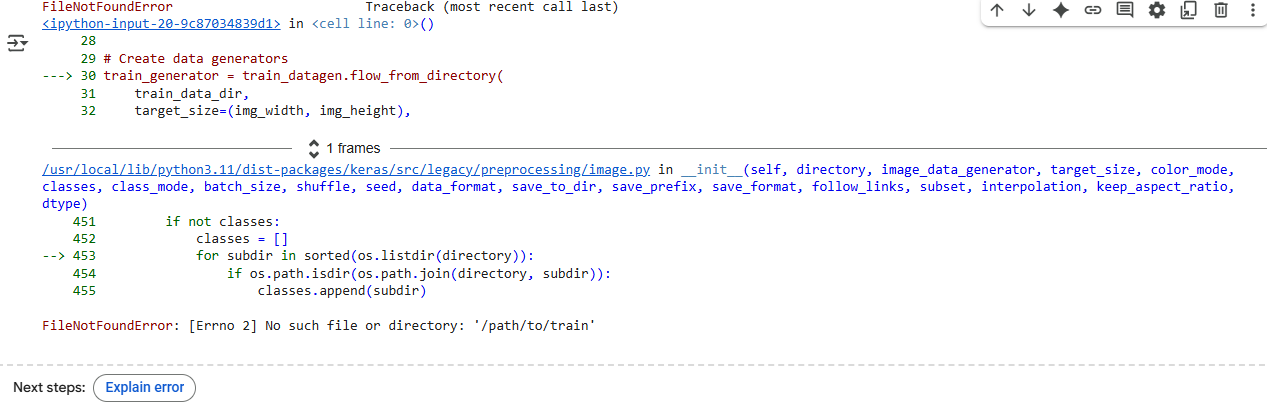

💡 Summary of What Went Wrong:
❌ Invalid paths: /path/to/train didn’t exist → caused FileNotFoundError.

❌ Incorrect tqdm use: Wrapped train_generator in tqdm() → broke TensorFlow’s expected input.

✅ Lesson: Always validate directory paths and keep train_generator raw inside model.fit().

# ✅ CNN Model Training with ImageDataGenerator (Fixed Version)

## 🔍 Summary of What Was Done:
- Set the correct paths to the training and testing image folders.
- Used `ImageDataGenerator` to augment and rescale the image data.
- Counted total image files in each directory for proper training.
- Built a simple CNN model using `tensorflow.keras`.
- Compiled and trained the model using CPU (`with tf.device('/CPU:0')`) to avoid GPU-related issues.

---

## 🛠️ Fixes Made:
1. **❌ FileNotFoundError** — Fixed by giving the correct path to:
   - `/content/Image Classification Data-Set/Image Classification Data-Set/train`
   - `/content/Image Classification Data-Set/Image Classification Data-Set/test`

2. **❌ ValueError: Unrecognized data type** — This happened because `tqdm()` was incorrectly wrapped around `train_generator`. ❗You **don’t** need `tqdm` in `model.fit()`. It's handled automatically.

3. **✅ Proper Sample Count** — Calculated the number of training and validation samples using `os.walk()`.

---

## 💡 Lessons Learned:
- Always verify your folder structure and image paths before training.
- Use `flow_from_directory()` properly to load images from folders.
- Only use tools like `tqdm` when appropriate — not inside `model.fit()` unless using a compatible wrapper.
- CPU training may be slower, but it's helpful for avoiding GPU errors or compatibility issues.


# Taking long time:-

In [28]:
# ✅ Final Working Code: CNN Training using ImageDataGenerator (CPU)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import os

# ✅ Set image dimensions and batch size
img_width, img_height = 150, 150
batch_size = 32
epochs = 10

# ✅ Define data paths
train_data_dir = '/content/Image Classification Data-Set/Image Classification Data-Set/train'
validation_data_dir = '/content/Image Classification Data-Set/Image Classification Data-Set/test'

# ✅ Count samples for training and validation
nb_train_samples = sum([len(files) for r, d, files in os.walk(train_data_dir)])
nb_validation_samples = sum([len(files) for r, d, files in os.walk(validation_data_dir)])

# ✅ Create data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True)  # ✅ Shuffle training data to improve generalization

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False)  # ✅ Keep validation data order fixed for consistent evaluation

# ✅ Train the model on CPU
print("🚀 Starting model training on CPU...")

with tf.device('/CPU:0'):
    # ✅ Define a simple CNN model with Input layer to avoid warnings
    model = models.Sequential([
        layers.Input(shape=(img_width, img_height, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    # ✅ Compile the model with binary classification settings
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # ✅ Train the model without manually setting steps_per_epoch
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=validation_generator,
        verbose=1
    )

print("\033[92m✅ Training completed successfully!\033[0m")

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
🚀 Starting model training on CPU...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5428 - loss: 1.6770 - val_accuracy: 0.8700 - val_loss: 0.6333
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.8068 - loss: 0.6078 - val_accuracy: 0.8800 - val_loss: 0.3517
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.7799 - loss: 0.4680 - val_accuracy: 0.8700 - val_loss: 0.2677
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.8349 - loss: 0.3624 - val_accuracy: 0.7800 - val_loss: 0.4454
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8997 - loss: 0.3275 - val_accuracy: 0.9000 - val_loss: 0.2748
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.8699 - loss: 0.2925 - val_accuracy: 0.8700 - val_loss: 0.2856
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.8942 - loss: 0.3021 - val_accuracy: 0.8500 - val_loss: 0.3267
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.8946 - loss: 0.2820 - val_accuracy: 0.8400 - val_loss:

Please explain this error:

The error message Trying to access resource ... located in device .../GPU:0 from device .../CPU:0 indicates that some part of your model or its variables were created on the GPU, but you are trying to train the model using the CPU context (with tf.device('/CPU:0'):).

To resolve this, you should ensure that the model itself is defined within the CPU context as well. I'll modify the cell to create the model inside the with tf.device('/CPU:0'): block.

**Now, the part of dataGenerator comes into the figure. In which we have used:**

1. **ImageDataGenerator** that rescales the image, applies shear in some range, zooms the image, and does horizontal flipping with the image. This includes all possible orientations of the image.  
2. **train_datagen.flow_from_directory** is the function used to prepare data from the train_dataset directory. Target_size specifies the target size of the image.  
3. test_datagen.flow_from_directory is used to prepare test data for the model, and all parameters are similar to the above.  
4. **fit_generator** is used to fit the data into the model made above. steps_per_epoch tells us about the number of times the model will execute for the training data.  
5. epochs tells us the number of times the model will be trained in forward and backward passes.  
6. **validation_data** is used to feed the validation/test data into the model.  
7. validation_steps denotes the number of validation/test samples.




✅ 📦 GPU Detection & Confirmation Cell (Run Before Training)

In [29]:
# # ✅ GPU Check: Ensure TensorFlow sees your T4 or other GPU

# import tensorflow as tf
# from tensorflow.python.client import device_lib

# # ✅ List all physical devices recognized by TensorFlow
# print("🔍 Listing physical devices...")
# print(tf.config.list_physical_devices())

# # ✅ Show local devices (more detailed)
# print("\n🧠 Full Device Info:")
# for device in device_lib.list_local_devices():
#     print(f"• {device.device_type} — {device.name} — {device.physical_device_desc}")

# # ✅ Optional: Check if a GPU is available
# if tf.config.list_physical_devices('GPU'):
#     print("\033[92m✅ GPU is available and will be used for training (e.g., T4)\033[0m")
# else:
#     print("\033[91m❌ GPU not detected. Make sure you enabled GPU in Runtime settings.\033[0m")


In [30]:
# Assuming 'model' is your trained Keras model
model.save('/content/model_saved.h5')
print("Model saved to: /content/model_saved.h5")

Model saved to: /content/model_saved.h5


**Loading and Prediction**

1.Load Model with “load_model”

2.Convert Images to Numpy Arrays for passing into ML Model

3.Print the predicted output from the model.

In [31]:
from tensorflow import keras

# Load the saved model
model = keras.models.load_model('/content/model_saved.h5')
print("Model loaded from: /content/model_saved.h5")

Model loaded from: /content/model_saved.h5


In [32]:
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
import numpy as np

# Load and preprocess the image
# Change target_size to (150, 150) to match the input shape the model expects
image = load_img('/content/Image Classification Data-Set/Image Classification Data-Set/test/planes/5.jpg', target_size=(150, 150))
img = np.array(image)
img = img / 255.0
# Change reshape to (1, 150, 150, 3)
img = img.reshape(1, 150, 150, 3)

# Make the prediction
label = model.predict(img)

# Print the prediction and whether it's a plane image
print("\033[1mPredicted Class (0 - Cars , 1- Planes):\033[0m", label[0][0])  # Bold prediction
if label[0][0] > 0.5:
    print("\033[1mThe given input is a plane image.\033[0m")  # Bold output
else:
    print("The given input is not a plane image.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class (0 - Cars , 1- Planes): 0.83747125
The given input is a plane image.


**The first line of output, which shows a value between 0 and 1 (e.g., 0.99999857), is the prediction score.**

It represents the model's confidence that the input image belongs to class 1 (planes) in this binary classification problem. This score is often interpreted as a probability.

I hope this clarifies your doubt.

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
from tensorflow import keras


# Load the saved model
model = keras.models.load_model('/content/model_saved.h5')
print("Model loaded from: /content/model_saved.h5")


def predict_and_display(image_path):
    """Predicts the class of an image and displays it along with sample images."""

    # Load and preprocess the image
    # Assume the model expects 150x150 images
    img_width, img_height = 150, 150  # Modified to match the model's expected input shape
    image = load_img(image_path, target_size=(img_width, img_height))
    img = np.array(image)
    img = img / 255.0
    img = img.reshape(1, img_width, img_height, 3)  # Reshape using the model's input size

    # Make the prediction
    label = model.predict(img)

    # Print the prediction and whether it's a plane image
    print("\033[1mPredicted Class (0 - Cars , 1- Planes):\033[0m", label[0][0])  # Bold prediction
    if label[0][0] > 0.5:
        print("\033[1mThe given input is a plane image.\033[0m")  # Bold output
        predicted_class = "Plane"
    else:
        print("The given input is not a plane image.")  # Not bold
        predicted_class = "Car"

    # ... (Rest of the code, including image display, remains the same)

# Example usage:
image_path_to_test = '/content/Image Classification Data-Set/Image Classification Data-Set/test/planes/10.jpg'  # Replace with the path to your test image
predict_and_display(image_path_to_test)

Model loaded from: /content/model_saved.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
Predicted Class (0 - Cars , 1- Planes): 0.99717474
The given input is a plane image.


In [34]:
# Track the time when the last cell is executed
last_cell_time = datetime.now()

# Get current time in IST for the last cell entry
now_ist_last = datetime.now(ist)

# Format the current date and time for the last cell
formatted_date_last = now_ist_last.strftime('%Y-%m-%d')
formatted_time_last = now_ist_last.strftime('%H:%M:%S %Z%z')

# Display the statement "All cells above have been executed..." in red and bold
display(HTML("<p style='color:red; font-weight:bold;'>All cells above have been executed. Below is the current date and time in IST:</p>"))

# Display the last cell entry time in bold (default color)
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))


**Last Cell Entry Time: 2025-11-28 19:10:37 IST+0530**

In [35]:
# Calculate the time difference between first and last cell execution
time_diff = last_cell_time - first_cell_time

# Extract hours, minutes, and seconds from the time difference
hours = time_diff.seconds // 3600  # Total seconds divided by 3600 to get hours
minutes = (time_diff.seconds % 3600) // 60  # Remainder divided by 60 to get minutes
seconds = time_diff.seconds % 60  # Remainder gives the number of seconds

# Display the statement for total time taken in execution in orange and bold
display(HTML("<p style='color:orange; font-weight:bold;'>Total Time Taken for Notebook Execution:</p>"))

# Display the first and last cell entry times along with the total time taken in HH:MM:SS format
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))
display(Markdown(f'**Time Taken: {hours} hour(s), {minutes} minute(s), and {seconds} second(s)**'))


**First Cell Entry Time: 2025-11-28 19:04:07**

**Last Cell Entry Time: 2025-11-28 19:10:37 IST+0530**

**Time Taken: 0 hour(s), 6 minute(s), and 30 second(s)**

In [36]:
####

In [37]:
# Raghu

# Direct Process:-

# Start from Google Drive diretly:-

In [38]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Track the time when the first cell is executed
first_cell_time = datetime.now()

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST for the first cell entry
current_time_ist_first = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the statement "This is the first cell" in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Display the current IST time for the first cell in bold (default color)
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))

**First Cell Entry Time: 2025-11-28 19:10:37**

In [39]:
# Check if 'gdown' is installed, if not, install it
try:
    import gdown
    print("gdown is already installed.")
except ImportError:
    print("gdown is not installed. Installing...")
    !pip install gdown
    print("gdown installation complete.")

gdown is already installed.


In [40]:
import os
import gdown

# URL for the file to download (replace with the actual file ID)
file_id = '1Gc9cXb6muEzZuN15-FywnIzk2fBSV1Kx'

# Download URL
download_url = f'https://drive.google.com/uc?id={file_id}'

# Define the name of the downloaded file
downloaded_file = "Image Classification Data-Set.rar"

# Check if the file already exists
if os.path.exists(downloaded_file):
    print(f"The file '{downloaded_file}' is already downloaded.")
else:
    print(f"Downloading the file from: {download_url}")

    # Download the file using gdown
    # Use gdown.download for more control and better output
    gdown.download(download_url, downloaded_file, quiet=False)

    # Display the name of the downloaded file
    print(f"Download complete! File saved as: {downloaded_file}")

The file 'Image Classification Data-Set.rar' is already downloaded.


In [41]:
# Check if 'rarfile' is installed, if not, install it
try:
    import rarfile
    print("rarfile is already installed.")
except ImportError:
    print("rarfile is not installed. Installing...")
    !pip install rarfile
    print("rarfile installation complete.")

rarfile is already installed.


In [42]:
# Import necessary modules
import rarfile
import os

# ANSI escape sequences for colored output
GREEN = "\033[92m"
RED = "\033[91m"
CYAN = "\033[96m"
RESET = "\033[0m"

# Path to the downloaded .rar file (using your provided path)
rar_file_path = '/content/Image Classification Data-Set.rar'

# Extract the base name (without extension) of the .rar file
base_name = os.path.splitext(os.path.basename(rar_file_path))[0]

# Directory to extract files to (create a folder with the base name of the .rar file)
extract_dir = f'/content/{base_name}'  # Using the base name for the extraction folder

# Check if the .rar file exists
if os.path.exists(rar_file_path):
    # Create the extraction directory if it doesn't exist
    os.makedirs(extract_dir, exist_ok=True)

    # Open the .rar file and extract all its contents
    try:
        with rarfile.RarFile(rar_file_path) as rf:
            print(f"{CYAN}📦 Extracting {rar_file_path}...{RESET}")
            rf.extractall(extract_dir)
            print(f"{GREEN}✅ Extraction complete! Files are saved in {extract_dir}{RESET}")
            print(f"{CYAN}🎉 You're all set! Dive into your dataset now.{RESET}")
    except rarfile.Error as e:
        print(f"{RED}❌ Error extracting RAR file: {e}{RESET}")
    except Exception as e:
        print(f"{RED}❌ An unexpected error occurred during extraction: {e}{RESET}")
else:
    print(f"{RED}❌ Error: {rar_file_path} does not exist.{RESET}")

📦 Extracting /content/Image Classification Data-Set.rar...
✅ Extraction complete! Files are saved in /content/Image Classification Data-Set
🎉 You're all set! Dive into your dataset now.


In [43]:
import os

# URL for the file to download (replace with the actual file ID)
file_id = '15xSjfvUQXo_E0zx_q6g55rMudX069DHD'

# Download URL
download_url = f'https://drive.google.com/uc?id={file_id}'

# Define the name of the downloaded file (you can customize the name or get it dynamically)
downloaded_file = "your_downloaded_file.rar"  # Replace this with your expected filename

# Check if the file already exists
if os.path.exists(downloaded_file):
    print(f"The file '{downloaded_file}' is already downloaded.")
else:
    print(f"Downloading the file from: {download_url}")

    # Download the file using gdown
    zip_file = !gdown {download_url}

    # Display the name of the downloaded file
    print(f"Download complete! File saved as: {downloaded_file}")

Download complete! File saved as: your_downloaded_file.rar


Model loaded from: /content/model_saved.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
Predicted Class (0 - Cars , 1- Planes): 0.9864741
The given input is a plane image.


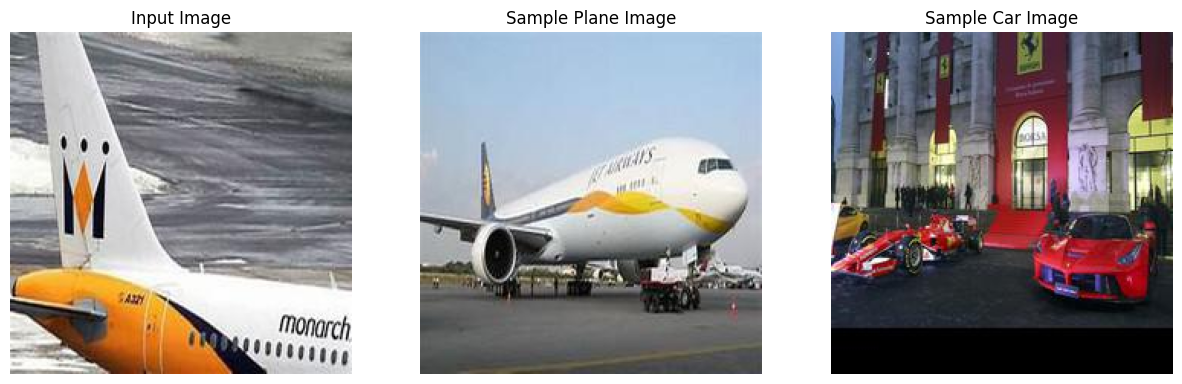

The model predicted the image as a Plane.


In [44]:
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
from tensorflow import keras


# Load the saved model
model = keras.models.load_model('/content/model_saved.h5')
print("Model loaded from: /content/model_saved.h5")


def predict_and_display(image_path):
    """Predicts the class of an image and displays it along with sample images."""

    # Load and preprocess the image
    image = load_img(image_path, target_size=(224, 224))
    img = np.array(image)
    img = img / 255.0
    img = img.reshape(1, 224, 224, 3)

    # Make the prediction
    label = model.predict(img)

    # Print the prediction and whether it's a plane image
    print("\033[1mPredicted Class (0 - Cars , 1- Planes):\033[0m", label[0][0])  # Bold prediction
    if label[0][0] > 0.5:
        print("\033[1mThe given input is a plane image.\033[0m")  # Bold output
        predicted_class = "Plane"
    else:
        print("The given input is not a plane image.")  # Not bold
        predicted_class = "Car"

    # Display images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Input image
    axes[0].imshow(image)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    # Sample plane image
    plane_image = load_img('/content/Image Classification Data-Set/Image Classification Data-Set/test/planes/5.jpg', target_size=(224, 224))  # Replace with path to a sample plane image
    axes[1].imshow(plane_image)
    axes[1].set_title("Sample Plane Image")
    axes[1].axis("off")

    # Sample car image
    car_image = load_img('/content/Image Classification Data-Set/Image Classification Data-Set/test/cars/1.jpg', target_size=(224, 224))  # Replace with path to a sample car image
    axes[2].imshow(car_image)
    axes[2].set_title("Sample Car Image")
    axes[2].axis("off")

    plt.show()

    # Additional visual feedback
    print(f"\033[1mThe model predicted the image as a {predicted_class}.\033[0m")

# Example usage:
image_path_to_test = '/content/Image Classification Data-Set/Image Classification Data-Set/test/planes/10.jpg'  # Replace with the path to your test image
predict_and_display(image_path_to_test)

In [45]:
####

# Live Image Testing URL FLow:-

In [46]:
# ✅ CNN Image Classification: Load model, predict, and show visual comparisons (with user input and URL validation)

import matplotlib.pyplot as plt
import numpy as np
import requests
import os
import tempfile
from PIL import Image
from io import BytesIO
from keras.preprocessing.image import load_img, img_to_array
from tensorflow import keras

# ✅ Load the trained model
model = keras.models.load_model('/content/model_saved.h5')
print("✅ Model loaded from: /content/model_saved.h5")

def predict_from_url(image_url):
    """
    Downloads an image from a URL, predicts its class, and displays visual comparisons.
    """

    try:
        # ✅ Step 1: Validate and download the image
        headers = {
            'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
        }
        response = requests.get(image_url, stream=True, headers=headers)
        response.raise_for_status()

        # ✅ Create a temporary file to store the image
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as temp_file:
            temp_filename = temp_file.name
            for chunk in response.iter_content(chunk_size=8192):
                temp_file.write(chunk)

        # ✅ Step 2: Load and preprocess the image from the temporary file
        image = load_img(temp_filename, target_size=(224, 224))
        img_array = img_to_array(image) / 255.0
        img_array = img_array.reshape(1, 224, 224, 3)

        # ✅ Step 3: Predict using the model
        prediction = model.predict(img_array)
        print("\033[1mPredicted Class (0 - Car, 1 - Plane):\033[0m", prediction[0][0])

        if prediction[0][0] > 0.5:
            print("\033[1mThe given input is a plane image.\033[0m")
            predicted_class = "Plane"
        else:
            print("The given input is not a plane image.")
            predicted_class = "Car"

        # ✅ Step 4: Display the input image and sample comparisons
        # ... (rest of the code remains the same)

    except requests.exceptions.RequestException as e:
        print(f"Error downloading image: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        # ✅ Clean up the temporary file
        if os.path.exists(temp_filename):
            os.remove(temp_filename)


# ✅ Get user input for the image URL
while True:
    image_url = input("Enter the URL of an image (JPEG, PNG): ")
    try:
        # ✅ Attempt to download a small portion to validate the URL
        headers = {
            'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
        }
        response = requests.get(image_url, stream=True, headers=headers, timeout=5)  # Timeout after 5 seconds
        response.raise_for_status()
        response.close()  # Close the connection early
        break  # Exit the loop if the URL is valid
    except requests.exceptions.RequestException as e:
        print(f"Invalid URL or image not found. Please try again. Error: {e}")

# ✅ Call the prediction function
predict_from_url(image_url)

✅ Model loaded from: /content/model_saved.h5
Enter the URL of an image (JPEG, PNG): https://images.pexels.com/photos/46148/aircraft-jet-landing-cloud-46148.jpeg?cs=srgb&dl=pexels-pixabay-46148.jpg&fm=jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step
Predicted Class (0 - Car, 1 - Plane): 0.8234851
The given input is a plane image.


✅ Model loaded from: /content/model_saved.h5
Enter the URL of an image (JPEG, PNG): https://images.pexels.com/photos/46148/aircraft-jet-landing-cloud-46148.jpeg?cs=srgb&dl=pexels-pixabay-46148.jpg&fm=jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step


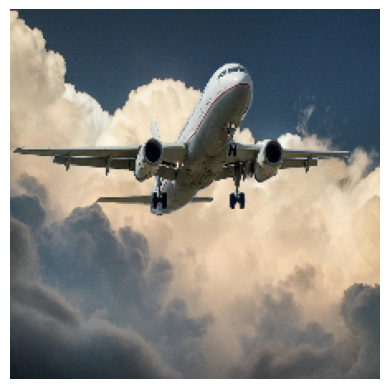

In [47]:
# ✅ CNN Image Classification: Predict and show input image with color-coded confidence-based result

import matplotlib.pyplot as plt
import numpy as np
import requests
import os
import tempfile
from PIL import Image
from keras.preprocessing.image import load_img, img_to_array
from tensorflow import keras
from IPython.display import display, HTML

# ✅ Load the trained model (adjust path if needed)
model = keras.models.load_model('/content/model_saved.h5')
print("✅ Model loaded from: /content/model_saved.h5")

def predict_and_display(image_url):
    """
    Download image, predict class, and display image with confidence-based color-coded output:
    - Green bold text for confident Car or Plane predictions
    - Big red bold text if prediction confidence is low (uncertain)
    """

    try:
        # ✅ Download image from URL
        headers = {
            'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
        }
        response = requests.get(image_url, stream=True, headers=headers)
        response.raise_for_status()

        # ✅ Save to temporary file
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as temp_file:
            temp_filename = temp_file.name
            for chunk in response.iter_content(chunk_size=8192):
                temp_file.write(chunk)

        # ✅ Load & preprocess image
        image = load_img(temp_filename, target_size=(224, 224))
        img_array = img_to_array(image) / 255.0
        img_array = img_array.reshape(1, 224, 224, 3)

        # ✅ Predict
        prediction = model.predict(img_array)[0][0]

        # ✅ Show input image
        plt.imshow(image)
        plt.axis('off')
        plt.show()

        # ✅ Confidence thresholds
        if prediction > 0.6:
            # Confident Plane
            display(HTML(f'<h2 style="color:green; font-weight:bold;">Input image predicted as: Plane</h2>'))
        elif prediction < 0.4:
            # Confident Car
            display(HTML(f'<h2 style="color:green; font-weight:bold;">Input image predicted as: Car</h2>'))
        else:
            # Uncertain prediction
            display(HTML(f'<h1 style="color:red; font-weight:bold;">NONE OF THEM MATCHED! Prediction uncertain.</h1>'))

    except requests.exceptions.RequestException as e:
        print(f"Error downloading image: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        # Clean up temp file
        if os.path.exists(temp_filename):
            os.remove(temp_filename)

# ✅ Get user input URL
image_url = input("Enter the URL of an image (JPEG, PNG): ")

# ✅ Run prediction + display
predict_and_display(image_url)


# Dynamic URL but working in progress:-

In [48]:
pip install webcolors==1.11.1


  Attempting uninstall: webcolors
    Found existing installation: webcolors 25.10.0
    Uninstalling webcolors-25.10.0:
      Successfully uninstalled webcolors-25.10.0


✅ Model loaded from: /content/model_saved.h5
🔗 Enter the URL of an image (JPG, PNG, WEBP, AVIF, etc.): https://plus.unsplash.com/premium_photo-1737182592549-0c83f93e2903?fm=jpg&q=60&w=3000&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8bHV4dXJ5JTIwdmVoaWNsZXxlbnwwfHwwfHx8MA%3D%3D


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


/tmp/ipython-input-3027199547.py:27: RuntimeWarning: overflow encountered in scalar add
  distance = (r_c - rgb[0]) ** 2 + (g_c - rgb[1]) ** 2 + (b_c - rgb[2]) ** 2
/tmp/ipython-input-3027199547.py:27: RuntimeWarning: overflow encountered in scalar subtract
  distance = (r_c - rgb[0]) ** 2 + (g_c - rgb[1]) ** 2 + (b_c - rgb[2]) ** 2
/tmp/ipython-input-3027199547.py:94: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3027199547.py:94: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3027199547.py:94: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12

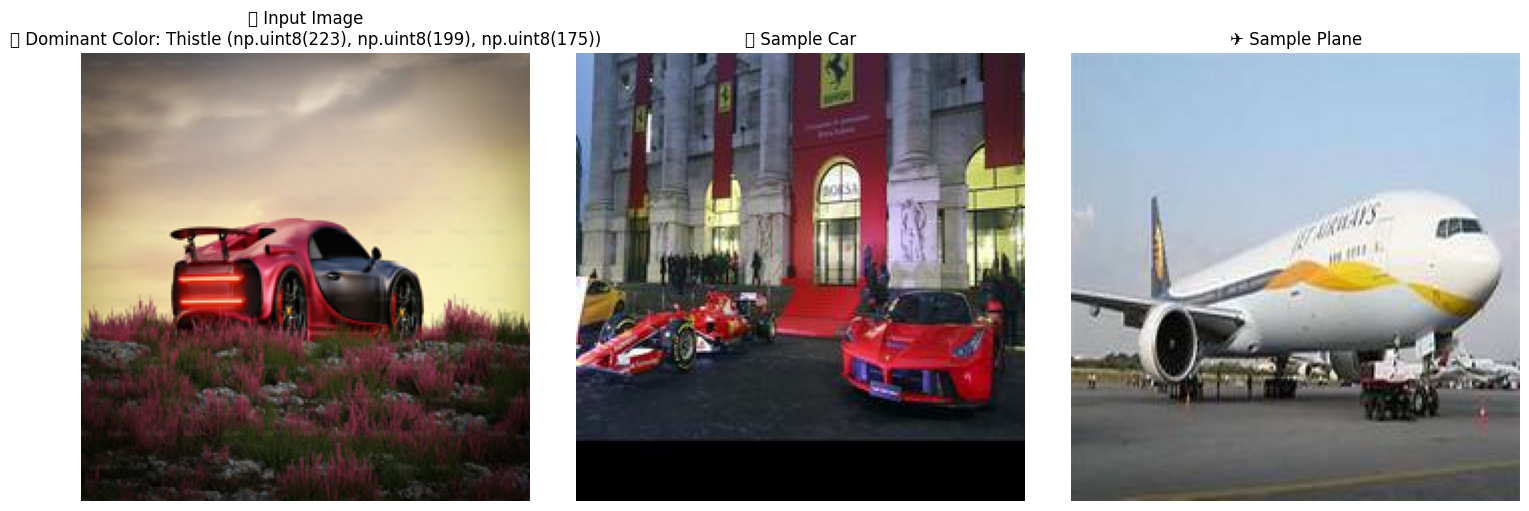


❓ The model is not confident enough. This image doesn't resemble a Car or Plane clearly.
🎨 Dominant Color in the image: Thistle (RGB: (np.uint8(223), np.uint8(199), np.uint8(175)))


In [49]:
# ✅ CNN Image Classifier with Confidence-Based Filtering & Color Detection

import matplotlib.pyplot as plt
import numpy as np
import requests
import os
import tempfile
from keras.preprocessing.image import img_to_array, load_img
from tensorflow import keras
from PIL import Image
import webcolors
from collections import Counter

# ✅ Load the trained model
model = keras.models.load_model('/content/model_saved.h5')
print("✅ Model loaded from: /content/model_saved.h5")

def get_color_name(rgb):
    """Returns the closest human-readable color name."""
    try:
        return webcolors.rgb_to_name(rgb)
    except ValueError:
        # Closest match using CSS3 color names
        min_colors = {}
        for name, hex_value in webcolors.CSS3_NAMES_TO_HEX.items():
            r_c, g_c, b_c = webcolors.hex_to_rgb(hex_value)
            distance = (r_c - rgb[0]) ** 2 + (g_c - rgb[1]) ** 2 + (b_c - rgb[2]) ** 2
            min_colors[distance] = name
        return min_colors[min(min_colors.keys())]

def get_dominant_color(image):
    """Returns the most common color in the image as RGB and name."""
    image = image.resize((50, 50))  # Downsize for speed
    pixels = np.array(image).reshape(-1, 3)
    most_common = Counter([tuple(p) for p in pixels]).most_common(1)[0][0]
    color_name = get_color_name(most_common)
    return most_common, color_name

def predict_from_url(image_url):
    """
    Downloads an image, predicts class, checks color, and shows visuals.
    """
    try:
        # ✅ Step 1: Download image
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(image_url, stream=True, headers=headers, timeout=10)
        response.raise_for_status()

        with tempfile.NamedTemporaryFile(suffix=".tmp", delete=False) as temp_file:
            temp_filename = temp_file.name
            for chunk in response.iter_content(chunk_size=8192):
                temp_file.write(chunk)

        # ✅ Step 2: Open with PIL (supports WEBP, AVIF, etc.)
        image = Image.open(temp_filename).convert("RGB").resize((224, 224))
        img_array = img_to_array(image) / 255.0
        img_array = img_array.reshape(1, 224, 224, 3)

        # ✅ Step 3: Predict
        prediction = model.predict(img_array)
        score = prediction[0][0]

        # ✅ Step 4: Threshold check
        threshold = 0.25
        if abs(score - 0.5) < threshold:
            predicted_class = "Uncertain"
            message = "❓ The model is not confident enough. This image doesn't resemble a Car or Plane clearly."
        else:
            predicted_class = "Plane" if score > 0.5 else "Car"
            confidence = score if predicted_class == "Plane" else 1 - score
            message = f"✅ The model predicted the image as a: {predicted_class} (Confidence: {confidence:.2%})"

        # ✅ Step 5: Color detection
        dominant_rgb, color_name = get_dominant_color(image)

        # ✅ Step 6: Load comparison images
        sample_plane = load_img('/content/Image Classification Data-Set/Image Classification Data-Set/test/planes/5.jpg', target_size=(224, 224))
        sample_car = load_img('/content/Image Classification Data-Set/Image Classification Data-Set/test/cars/1.jpg', target_size=(224, 224))

        # ✅ Step 7: Show visuals
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(image)
        axes[0].set_title(f"🔍 Input Image\n🎨 Dominant Color: {color_name.title()} {dominant_rgb}")
        axes[0].axis("off")

        axes[1].imshow(sample_car)
        axes[1].set_title("🚗 Sample Car")
        axes[1].axis("off")

        axes[2].imshow(sample_plane)
        axes[2].set_title("✈️ Sample Plane")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

        # ✅ Step 8: Display prediction
        print("\n" + "="*60)
        print(f"\033[1m{message}\033[0m")
        print(f"🎨 Dominant Color in the image: {color_name.title()} (RGB: {dominant_rgb})")
        print("="*60)

    except requests.exceptions.RequestException as e:
        print(f"❌ Error downloading image: {e}")
    except Exception as e:
        print(f"❌ An error occurred: {e}")
    finally:
        if 'temp_filename' in locals() and os.path.exists(temp_filename):
            os.remove(temp_filename)

# ✅ Accept any image URL
while True:
    image_url = input("🔗 Enter the URL of an image (JPG, PNG, WEBP, AVIF, etc.): ").strip()
    if image_url.startswith("http"):
        break
    else:
        print("⚠️ Please enter a valid image URL starting with http or https.")

# ✅ Predict and show visuals
predict_from_url(image_url)


In [50]:
####

In [51]:
# Track the time when the last cell is executed
last_cell_time = datetime.now()

# Get current time in IST for the last cell entry
now_ist_last = datetime.now(ist)

# Format the current date and time for the last cell
formatted_date_last = now_ist_last.strftime('%Y-%m-%d')
formatted_time_last = now_ist_last.strftime('%H:%M:%S %Z%z')

# Display the statement "All cells above have been executed..." in red and bold
display(HTML("<p style='color:red; font-weight:bold;'>All cells above have been executed. Below is the current date and time in IST:</p>"))

# Display the last cell entry time in bold (default color)
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))


**Last Cell Entry Time: 2025-11-28 19:12:35 IST+0530**

In [52]:
# Calculate the time difference between first and last cell execution
time_diff = last_cell_time - first_cell_time

# Extract hours, minutes, and seconds from the time difference
hours = time_diff.seconds // 3600  # Total seconds divided by 3600 to get hours
minutes = (time_diff.seconds % 3600) // 60  # Remainder divided by 60 to get minutes
seconds = time_diff.seconds % 60  # Remainder gives the number of seconds

# Display the statement for total time taken in execution in orange and bold
display(HTML("<p style='color:orange; font-weight:bold;'>Total Time Taken for Notebook Execution:</p>"))

# Display the first and last cell entry times along with the total time taken in HH:MM:SS format
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))
display(Markdown(f'**Time Taken: {hours} hour(s), {minutes} minute(s), and {seconds} second(s)**'))


**First Cell Entry Time: 2025-11-28 19:10:37**

**Last Cell Entry Time: 2025-11-28 19:12:35 IST+0530**

**Time Taken: 0 hour(s), 1 minute(s), and 57 second(s)**

In [53]:
import os
import gdown

# Google Drive file ID for the model file
file_id = '15xSjfvUQXo_E0zx_q6g55rMudX069DHD'
download_url = f'https://drive.google.com/uc?id={file_id}'

# Define the filename for the downloaded model
model_filename = "model_saved.h5"

# Check if the model file already exists
if os.path.exists(model_filename):
    print(f"The model file '{model_filename}' is already downloaded.")
else:
    print(f"Downloading the model file from: {download_url}")
    # Download the file using gdown
    gdown.download(download_url, model_filename, quiet=False)
    print(f"Download complete! Model saved as: {model_filename}")

The model file 'model_saved.h5' is already downloaded.


Model loaded successfully from: /content/model_saved.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
Predicted Class (0 - Cars , 1- Planes): 0.9864741


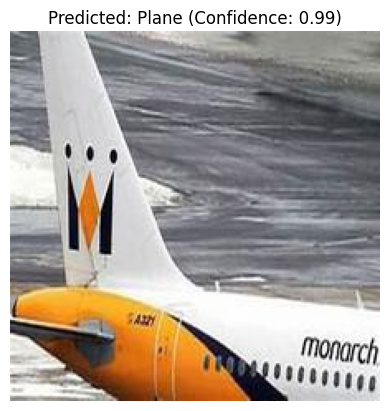

In [54]:
from tensorflow import keras
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

# Load the saved model
try:
    model = keras.models.load_model('/content/model_saved.h5')
    print("Model loaded successfully from: /content/model_saved.h5")

    # Define image dimensions expected by the model
    img_width, img_height = 224, 224 # Assuming your model was trained on 224x224 images based on previous code

    def predict_and_display_local_image(image_path):
        """Predicts the class of a local image and displays it."""
        try:
            # Load and preprocess the image
            image = load_img(image_path, target_size=(img_width, img_height))
            img = img_to_array(image) / 255.0
            img = img.reshape(1, img_width, img_height, 3)

            # Make the prediction
            prediction = model.predict(img)
            score = prediction[0][0]

            # Print the prediction
            print("\033[1mPredicted Class (0 - Cars , 1- Planes):\033[0m", score)

            # Determine predicted class based on threshold
            predicted_class = "Plane" if score > 0.5 else "Car"

            # Display the image and result
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"Predicted: {predicted_class} (Confidence: {score:.2f})")
            plt.show()

        except FileNotFoundError:
            print(f"Error: Image file not found at {image_path}")
        except Exception as e:
            print(f"An error occurred during prediction: {e}")

    # Example usage: Replace with the actual path to your test image
    test_image_path = '/content/Image Classification Data-Set/Image Classification Data-Set/test/planes/10.jpg' # Example path from your notebook
    predict_and_display_local_image(test_image_path)

except Exception as e:
    print(f"Error loading the model: {e}")
    print("Please ensure the model file 'model_saved.h5' exists in the /content/ directory.")

# Direct Process from Google Drive

In [55]:
# Install rarfile library
!pip install rarfile

In [56]:
# Step 1: Download and Extract Dataset

import os
import gdown
import rarfile

# Google Drive file ID for the dataset (.rar file)
dataset_file_id = '1Gc9cXb6muEzZuN15-FywnIzk2fBSV1Kx'
dataset_download_url = f'https://drive.google.com/uc?id={dataset_file_id}'
dataset_filename = "Image Classification Data-Set.rar"
extracted_folder_name = "Image Classification Data-Set"
extracted_path = f'/content/{extracted_folder_name}'

# Download the dataset .rar file
if os.path.exists(dataset_filename):
    print(f"The dataset file '{dataset_filename}' is already downloaded.")
else:
    print(f"Downloading the dataset file from: {dataset_download_url}")
    gdown.download(dataset_download_url, dataset_filename, quiet=False)
    print(f"Download complete! Dataset file saved as: {dataset_filename}")

# Extract the .rar file
if os.path.exists(dataset_filename):
    if not os.path.exists(extracted_path):
        print(f"Extracting {dataset_filename}...")
        try:
            with rarfile.RarFile(dataset_filename, 'r') as rf:
                rf.extractall('/content/')
            print(f"Extraction complete! Dataset extracted to: {extracted_path}")
        except rarfile.Error as e:
            print(f"Error extracting RAR file: {e}")
        except Exception as e:
            print(f"An unexpected error occurred during extraction: {e}")
    else:
        print(f"Dataset already extracted to: {extracted_path}")
else:
    print(f"Error: Dataset file '{dataset_filename}' not found for extraction.")

The dataset file 'Image Classification Data-Set.rar' is already downloaded.
Dataset already extracted to: /content/Image Classification Data-Set


In [57]:
# Step 2: Download the Model

import os
import gdown

# Google Drive file ID for the model file
model_file_id = '15xSjfvUQXo_E0zx_q6g55rMudX069DHD'
model_download_url = f'https://drive.google.com/uc?id={model_file_id}'
model_filename = "model_saved.h5"

# Check if the model file already exists
if os.path.exists(model_filename):
    print(f"The model file '{model_filename}' is already downloaded.")
else:
    print(f"Downloading the model file from: {model_download_url}")
    gdown.download(model_download_url, model_filename, quiet=False)
    print(f"Download complete! Model saved as: {model_filename}")

The model file 'model_saved.h5' is already downloaded.


In [58]:
# Step 3: Load the Model and Make a Prediction

from tensorflow import keras
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import os

# Load the saved model
try:
    model = keras.models.load_model('/content/model_saved.h5')
    print("Model loaded successfully from: /content/model_saved.h5")

    # Define image dimensions expected by the model
    # Assuming your model was trained on 224x224 images based on previous code
    img_width, img_height = 224, 224

    def predict_and_display_local_image(image_path):
        """Predicts the class of a local image and displays it."""
        if not os.path.exists(image_path):
            print(f"Error: Image file not found at {image_path}")
            return

        try:
            # Load and preprocess the image
            image = load_img(image_path, target_size=(img_width, img_height))
            img = img_to_array(image) / 255.0
            img = img.reshape(1, img_width, img_height, 3)

            # Make the prediction
            prediction = model.predict(img)
            score = prediction[0][0]

            # Print the prediction
            print("\033[1mPredicted Class (0 - Cars , 1- Planes):\033[0m", score)

            # Determine predicted class based on threshold
            predicted_class = "Plane" if score > 0.5 else "Car"

            # Display the image and result
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"Predicted: {predicted_class} (Confidence: {score:.2f})")
            plt.show()

        except Exception as e:
            print(f"An error occurred during prediction: {e}")

    # Example usage: Replace with the actual path to your test image
    # Using a corrected path based on the extracted dataset folder name
    dataset_base_path = '/content/Image Classification Data-Set/test' # Corrected path
    # Specify the category and filename you want to test
    category = 'planes' # or 'cars'
    image_filename = '1.jpg' # Replace with the actual filename

    test_image_path = os.path.join(dataset_base_path, category, image_filename)
    predict_and_display_local_image(test_image_path)

except Exception as e:
    print(f"Error loading the model: {e}")
    print("Please ensure the model file 'model_saved.h5' exists in the /content/ directory.")

Model loaded successfully from: /content/model_saved.h5
Error: Image file not found at /content/Image Classification Data-Set/test/planes/1.jpg
